# SmolVLA Replication Analysis

Reads:
- [`results_smolvla/rollouts_smolvla.db`](results_smolvla/rollouts_smolvla.db) from [`test_smolvla_jennifer.ipynb`](test_smolvla_jennifer.ipynb)
- [`results_v2/rollouts_v2.db`](results_v2/rollouts_v2.db) (π0.5, read-only for cross-model comparison)

**Goal:** Test whether P&P detector signal transfers to the 450M-parameter SmolVLA policy on the same fixed 80-episode slice.

Sections: **0** design · **A** SmolVLA SR + instability · **C** detector metrics · **E** cross-model table · **D** findings


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os, sqlite3, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from IPython.display import display

SHARED = '/content/drive/MyDrive/cs159-sp26'
PI05_RESULTS = f'{SHARED}/results_v2'
PI05_DB = f'{PI05_RESULTS}/rollouts_v2.db'
SMOLVLA_RESULTS = f'{SHARED}/results_smolvla'
SMOLVLA_DB = f'{SMOLVLA_RESULTS}/rollouts_smolvla.db'
FIGURES_DIR = f'{SMOLVLA_RESULTS}/figures_smolvla'
FINAL_FIGURES_DIR = f'{FIGURES_DIR}/final'

for path, fallback in [(SMOLVLA_DB, 'results_smolvla/rollouts_smolvla.db'),
                       (PI05_DB, 'results_v2/rollouts_v2.db')]:
    if not os.path.isfile(path):
        local = Path(fallback)
        if local.is_file():
            if 'smolvla' in fallback:
                SMOLVLA_RESULTS = str(local.parent)
                SMOLVLA_DB = str(local)
            else:
                PI05_RESULTS = str(local.parent)
                PI05_DB = str(local)

os.makedirs(FINAL_FIGURES_DIR, exist_ok=True)

def save_fig(name, final=True):
    d = FINAL_FIGURES_DIR if final else FIGURES_DIR
    os.makedirs(d, exist_ok=True)
    path = os.path.join(d, f'final_smolvla_{name}.png' if final else f'smolvla_{name}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Wrote {path}')

FINAL_STEP_CONFIGS = [(2, 3), (3, 4), (4, 5)]
EPISODE_KEYS = ['suite', 'task_idx', 'episode_idx', 'init_state_hash']
INSTABILITY_COLS = ['action_delta_l2_mean', 'action_delta_l2_max', 'action_var_mean',
                    'gripper_flip_count', 'gripper_flip_rate', 'chunk_disagreement_mean']

con_smol = sqlite3.connect(SMOLVLA_DB)
smol_rollouts = pd.read_sql('SELECT * FROM rollouts', con_smol)
con_pi = sqlite3.connect(PI05_DB)
pi05_rollouts = pd.read_sql('SELECT * FROM rollouts', con_pi)

smol_df = smol_rollouts[smol_rollouts['final_eval_slice'] == 1].copy()
pi05_df = pi05_rollouts[pi05_rollouts['final_eval_slice'] == 1].copy()
print(f'SmolVLA slice rows: {len(smol_df)}')
print(f'π0.5 slice rows:    {len(pi05_df)}')


SmolVLA slice rows: 100
π0.5 slice rows:    644


---
## Section 0: Experiment design

Same **80 episodes** as π0.5 v2 (`libero_goal` + `libero_spatial`, top-8 failure-prone tasks).

| Method | SmolVLA run | Purpose |
|--------|-------------|---------|
| `vanilla` | 10 Euler steps, P&P off | Baseline SR + instability |
| `pnp_uncertainty_only` | P&P at steps (2,3), (3,4), (4,5), K=3 | Detector signal |

**Hypothesis:** If P&P uncertainty is architecture-agnostic, SmolVLA should show similar U↔failure and U↔jerk correlations as π0.5 on this slice.


In [3]:
def describe_slice(df, label):
    if df.empty:
        print(f'{label}: no rows')
        return
    tasks = df.groupby(['suite', 'task_idx']).size()
    methods = df['method'].value_counts().to_dict()
    print(f'=== {label} ===')
    print(f'  Episodes (unique keys): {df[EPISODE_KEYS].drop_duplicates().shape[0]}')
    print(f'  Methods: {methods}')
    if 'vanilla' in methods:
        v = df[df['method'] == 'vanilla']
        null_inst = v['action_delta_l2_mean'].isna().sum()
        if null_inst:
            print(f'  WARNING: {null_inst} vanilla rows missing action_delta_l2_mean')
        else:
            print(f'  vanilla SR: {v["success"].mean():.1%}')

describe_slice(smol_df, 'SmolVLA')
describe_slice(pi05_df, 'π0.5')

vanilla_null_pi = pi05_df.query("method=='vanilla'")['action_delta_l2_mean'].isna().sum()
if vanilla_null_pi:
    print(f'\nπ0.5 backfill incomplete: {vanilla_null_pi} vanilla rows still NULL — run test_smolvla Section 6b')
else:
    print('\nπ0.5 vanilla instability backfill: OK')


=== SmolVLA ===
  Episodes (unique keys): 80
  Methods: {'vanilla': 80, 'pnp_uncertainty_only': 20}
  vanilla SR: 70.0%
=== π0.5 ===
  Episodes (unique keys): 80
  Methods: {'pnp_uncertainty_only': 240, 'pnp_refinement': 240, 'vanilla': 80, 'extra_steps': 80, 'multi_sample_select': 4}
  vanilla SR: 76.2%

π0.5 vanilla instability backfill: OK


---
## Section A: SmolVLA vanilla SR + instability

=== SmolVLA method summary ===


,method,n_episodes,success_rate,action_delta_l2_mean,u_mean_episode
0,pnp_uncertainty_only,18,0.6667,0.4319,0.2003
1,vanilla,80,0.7000,0.4614,NaN


Wrote /content/drive/MyDrive/cs159-sp26/results_smolvla/figures_smolvla/final/final_smolvla_success_by_method.png


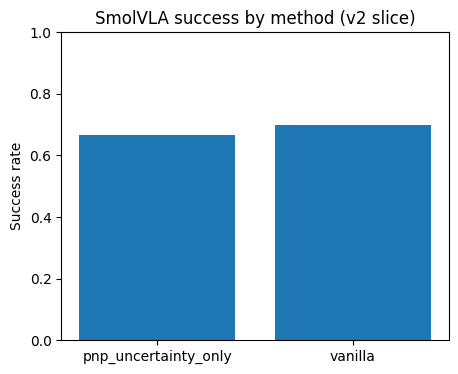

In [4]:
def collapse_step_configs(df, success_agg='max'):
    agg = {'success': success_agg}
    for col in ['u_mean_episode', 'n_steps'] + INSTABILITY_COLS:
        if col in df.columns:
            agg[col] = 'mean'
    return df.groupby(['method'] + EPISODE_KEYS, as_index=False).agg(agg)

smol_episode_df = collapse_step_configs(smol_df)
method_summary = (
    smol_episode_df.groupby('method')
    .agg(n_episodes=('success', 'count'), success_rate=('success', 'mean'),
         action_delta_l2_mean=('action_delta_l2_mean', 'mean'),
         u_mean_episode=('u_mean_episode', 'mean'))
    .reset_index()
)
print('=== SmolVLA method summary ===')
display(method_summary.round(4))
method_summary.to_csv(os.path.join(SMOLVLA_RESULTS, 'final_smolvla_method_comparison.csv'), index=False)

if not method_summary.empty:
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(method_summary['method'], method_summary['success_rate'])
    ax.set_ylabel('Success rate')
    ax.set_title('SmolVLA success by method (v2 slice)')
    ax.set_ylim(0, 1)
    save_fig('success_by_method')
    plt.show()


---
## Section C: SmolVLA detector analysis

=== SmolVLA detector metrics ===


,model,step_config,n,pearson_r,spearman_u_vs_success,roc_auc,pr_auc,spearman_u_vs_action_delta_l2_mean,best_threshold,best_precision,best_recall,best_f1
0,smolvla,"[2, 3]",4,0.2189,0.0000,0.5,0.7500,0.2000,0.2071,0.5,1.0,0.6667
1,smolvla,"[4, 5]",16,-0.0958,-0.1609,0.6,0.6175,0.3382,0.2162,1.0,0.4,0.5714


Wrote /content/drive/MyDrive/cs159-sp26/results_smolvla/figures_smolvla/final/final_smolvla_uncertainty_success_failure.png


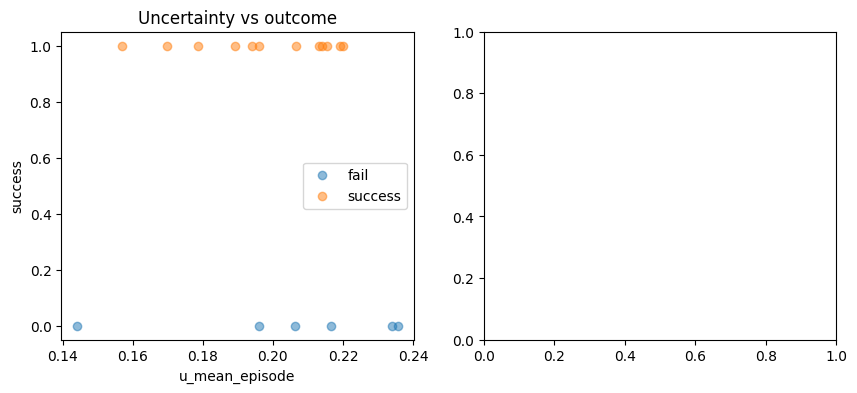

Wrote /content/drive/MyDrive/cs159-sp26/results_smolvla/figures_smolvla/final/final_smolvla_uncertainty_vs_instability.png


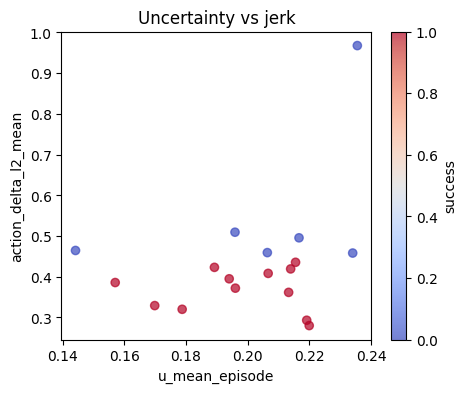

Wrote /content/drive/MyDrive/cs159-sp26/results_smolvla/figures_smolvla/final/final_smolvla_step_config_comparison.png


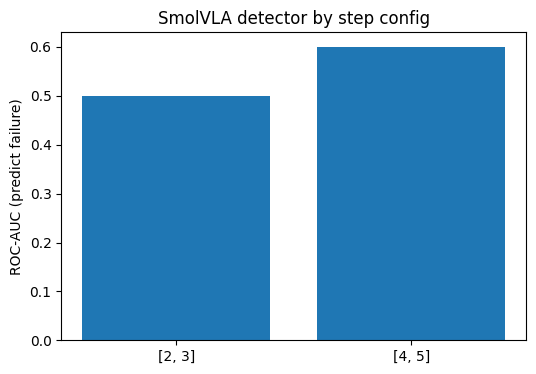

In [5]:
try:
    from sklearn.metrics import roc_auc_score, average_precision_score
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn'])
    from sklearn.metrics import roc_auc_score, average_precision_score


def threshold_curve(df, u_col='u_mean_episode', label_col='success'):
    y_true = 1 - df[label_col].astype(int)
    scores = df[u_col].astype(float)
    thresholds = np.linspace(scores.min(), scores.max(), 100)
    best = {'f1': -1}
    for t in thresholds:
        pred = (scores >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        prec = tp / (tp + fp) if (tp + fp) else 0
        rec = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
        if f1 > best.get('f1', -1):
            best = {'threshold': t, 'precision': prec, 'recall': rec, 'f1': f1}
    return best


def compute_detector_metrics(df, model_name):
    det = df[df['method'] == 'pnp_uncertainty_only'].copy()
    if det.empty:
        return pd.DataFrame()
    rows = []
    for step_cfg in sorted(det['pnp_step_indices'].dropna().unique()):
        sub = det[det['pnp_step_indices'] == step_cfg]
        if sub['success'].nunique() < 2:
            continue
        u = sub['u_mean_episode'].astype(float)
        y_fail = 1 - sub['success'].astype(int)
        r_p, _ = stats.pearsonr(u, sub['success'])
        r_s, _ = stats.spearmanr(u, sub['success'])
        row = {
            'model': model_name,
            'step_config': step_cfg,
            'n': len(sub),
            'pearson_r': r_p,
            'spearman_u_vs_success': r_s,
            'roc_auc': roc_auc_score(y_fail, u),
            'pr_auc': average_precision_score(y_fail, u),
        }
        if 'action_delta_l2_mean' in sub.columns and sub['action_delta_l2_mean'].notna().any():
            row['spearman_u_vs_action_delta_l2_mean'] = stats.spearmanr(
                u, sub['action_delta_l2_mean'].astype(float))[0]
        best = threshold_curve(sub)
        row.update({f'best_{k}': v for k, v in best.items()})
        rows.append(row)
    return pd.DataFrame(rows)

smol_det = compute_detector_metrics(smol_df, 'smolvla')
pi05_det = compute_detector_metrics(pi05_df, 'pi0.5')

if not smol_det.empty:
    print('=== SmolVLA detector metrics ===')
    display(smol_det.round(4))
    smol_det.to_csv(os.path.join(SMOLVLA_RESULTS, 'final_smolvla_detector_metrics.csv'), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sub = collapse_step_configs(smol_df[smol_df['method'] == 'pnp_uncertainty_only'])
    ax = axes[0]
    for s in [0, 1]:
        m = sub['success'] == s
        ax.scatter(sub.loc[m, 'u_mean_episode'], sub.loc[m, 'success'], alpha=0.5,
                   label='success' if s else 'fail')
    ax.set_xlabel('u_mean_episode'); ax.set_ylabel('success'); ax.set_title('Uncertainty vs outcome'); ax.legend()
    save_fig('uncertainty_success_failure')
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    sc = ax.scatter(sub['u_mean_episode'], sub['action_delta_l2_mean'], c=sub['success'], cmap='coolwarm', alpha=0.7)
    ax.set_xlabel('u_mean_episode'); ax.set_ylabel('action_delta_l2_mean'); ax.set_title('Uncertainty vs jerk')
    plt.colorbar(sc, ax=ax, label='success')
    save_fig('uncertainty_vs_instability')
    plt.show()

    if len(smol_det) > 1:
        fig, ax = plt.subplots(figsize=(6, 4))
        x = range(len(smol_det))
        ax.bar(x, smol_det['roc_auc'], tick_label=smol_det['step_config'])
        ax.set_ylabel('ROC-AUC (predict failure)')
        ax.set_title('SmolVLA detector by step config')
        save_fig('step_config_comparison')
        plt.show()


---
## Section E: Cross-model transfer table

=== Cross-model detector transfer (neurips placeholder table) ===


,model,n_episodes,vanilla_sr,roc_auc_mean,pr_auc_mean,spearman_u_vs_success,spearman_u_vs_action_delta_l2_mean,best_f1_mean
0,pi0.5,80,0.7625,0.8662,0.7760,-0.5539,NaN,0.7525
1,smolvla,16,0.7000,0.5500,0.6838,-0.0804,0.2691,0.6190


Wrote /content/drive/MyDrive/cs159-sp26/results_smolvla/figures_smolvla/final/final_smolvla_cross_model_detector.png


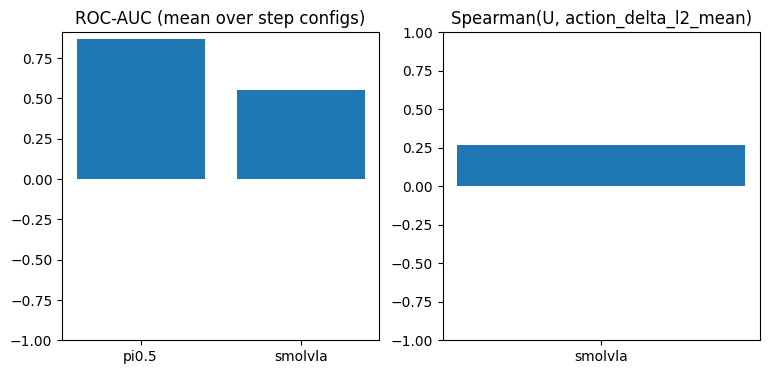

In [6]:
def aggregate_detector(det_df, model_name, pi05_vanilla_sr=None, smol_vanilla_sr=None):
    if det_df.empty:
        return {'model': model_name, 'n_episodes': 0}
    vanilla_sr = None
    if model_name == 'pi0.5':
        v = pi05_df[pi05_df['method'] == 'vanilla']
        vanilla_sr = v['success'].mean() if len(v) else None
    else:
        v = smol_df[smol_df['method'] == 'vanilla']
        vanilla_sr = v['success'].mean() if len(v) else None
    return {
        'model': model_name,
        'n_episodes': int(det_df['n'].max()) if 'n' in det_df else 0,
        'vanilla_sr': vanilla_sr,
        'roc_auc_mean': det_df['roc_auc'].mean(),
        'pr_auc_mean': det_df['pr_auc'].mean(),
        'spearman_u_vs_success': det_df['spearman_u_vs_success'].mean(),
        'spearman_u_vs_action_delta_l2_mean': det_df.get(
            'spearman_u_vs_action_delta_l2_mean', pd.Series(dtype=float)).mean(),
        'best_f1_mean': det_df.get('best_f1', pd.Series(dtype=float)).mean(),
    }

cross_rows = []
if not pi05_det.empty:
    cross_rows.append(aggregate_detector(pi05_det, 'pi0.5'))
if not smol_det.empty:
    cross_rows.append(aggregate_detector(smol_det, 'smolvla'))

cross_df = pd.DataFrame(cross_rows)
print('=== Cross-model detector transfer (neurips placeholder table) ===')
display(cross_df.round(4))
cross_df.to_csv(os.path.join(SMOLVLA_RESULTS, 'final_smolvla_cross_model.csv'), index=False)

if len(cross_df) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    metrics = ['roc_auc_mean', 'spearman_u_vs_action_delta_l2_mean']
    titles = ['ROC-AUC (mean over step configs)', 'Spearman(U, action_delta_l2_mean)']
    for ax, m, t in zip(axes, metrics, titles):
        if m in cross_df.columns:
            ax.bar(cross_df['model'], cross_df[m])
            ax.set_title(t)
            ax.set_ylim(-1, 1 if 'spearman' in m else None)
    save_fig('cross_model_detector')
    plt.show()


---
## Section D: Failure taxonomy + findings

In [7]:
def classify_failure_modes(episode_df, u_col='u_mean_episode', inst_col='action_delta_l2_mean'):
    det = episode_df[episode_df['method'] == 'pnp_uncertainty_only'].copy()
    if det.empty:
        return pd.DataFrame()
    det = collapse_step_configs(det)
    u_med = det[u_col].median()
    inst_med = det[inst_col].median() if inst_col in det and det[inst_col].notna().any() else 0
    labels = []
    for _, r in det.iterrows():
        hi_u = r[u_col] >= u_med
        hi_i = r.get(inst_col, 0) >= inst_med if pd.notna(r.get(inst_col)) else False
        if not r['success']:
            if hi_u and hi_i:
                tax = 'high_U_high_instability_failure'
            elif not hi_u and not hi_i:
                tax = 'low_U_low_instability_failure'
            elif hi_u:
                tax = 'high_U_low_instability_failure'
            else:
                tax = 'low_U_high_instability_failure'
        else:
            tax = 'high_U_success' if hi_u else 'low_U_success'
        labels.append({**{k: r[k] for k in EPISODE_KEYS}, 'taxonomy': tax, 'success': r['success'],
                       'u_mean_episode': r[u_col]})
    return pd.DataFrame(labels)

taxonomy_df = classify_failure_modes(smol_df)
if not taxonomy_df.empty:
    print('=== SmolVLA failure taxonomy ===')
    display(taxonomy_df['taxonomy'].value_counts())
    taxonomy_df.to_csv(os.path.join(SMOLVLA_RESULTS, 'final_smolvla_failure_taxonomy.csv'), index=False)


def summarize_smolvla_findings(cross_df, smol_det, method_summary):
    print('=' * 72)
    print('SMOLVLA REPLICATION FINDINGS')
    print('=' * 72)
    if not method_summary.empty and 'vanilla' in method_summary['method'].values:
        sr = method_summary.loc[method_summary['method'] == 'vanilla', 'success_rate'].iloc[0]
        print(f'1. SmolVLA vanilla SR on v2 slice: {sr:.1%}')
    if not smol_det.empty:
        print(f'2. SmolVLA detector: mean ROC-AUC={smol_det["roc_auc"].mean():.3f}, '
              f'mean Spearman(U,success)={smol_det["spearman_u_vs_success"].mean():.3f}')
        if 'spearman_u_vs_action_delta_l2_mean' in smol_det:
            print(f'   mean Spearman(U,jerk)={smol_det["spearman_u_vs_action_delta_l2_mean"].mean():.3f}')
    if len(cross_df) >= 2:
        pi = cross_df[cross_df['model'] == 'pi0.5'].iloc[0]
        sm = cross_df[cross_df['model'] == 'smolvla'].iloc[0]
        print('3. Transfer vs π0.5:')
        print(f'   π0.5     ROC-AUC={pi.get("roc_auc_mean", float("nan")):.3f}  vanilla SR={pi.get("vanilla_sr", float("nan")):.1%}')
        print(f'   SmolVLA  ROC-AUC={sm.get("roc_auc_mean", float("nan")):.3f}  vanilla SR={sm.get("vanilla_sr", float("nan")):.1%}')
        delta_auc = sm.get('roc_auc_mean', 0) - pi.get('roc_auc_mean', 0)
        print(f'   Δ ROC-AUC (SmolVLA - π0.5) = {delta_auc:+.3f}')
    print('\n4. CAVEATS: same slice, different absolute SR; detector measures instability not correctness.')
    print('=' * 72)

summarize_smolvla_findings(cross_df, smol_det, method_summary)


=== SmolVLA failure taxonomy ===


,count
taxonomy,
high_U_success,6
low_U_success,6
low_U_high_instability_failure,3
high_U_high_instability_failure,3


SMOLVLA REPLICATION FINDINGS
1. SmolVLA vanilla SR on v2 slice: 70.0%
2. SmolVLA detector: mean ROC-AUC=0.550, mean Spearman(U,success)=-0.080
   mean Spearman(U,jerk)=0.269
3. Transfer vs π0.5:
   π0.5     ROC-AUC=0.866  vanilla SR=76.2%
   SmolVLA  ROC-AUC=0.550  vanilla SR=70.0%
   Δ ROC-AUC (SmolVLA - π0.5) = -0.316

4. CAVEATS: same slice, different absolute SR; detector measures instability not correctness.
